# Machine Learning Basics

In [6]:
# -------------------------------------------------------------
# IMPORT LIBRARIES
# -------------------------------------------------------------
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, roc_curve, auc,
    accuracy_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Linear Regression

1. LINEAR REGRESSION – Predict Tip from Total Bill


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Linear Regression Metrics:
MAE: 0.6208580000398983
MSE: 0.5688142529229536
RMSE: 0.7541977545199625
R² Score: 0.5449381659234664


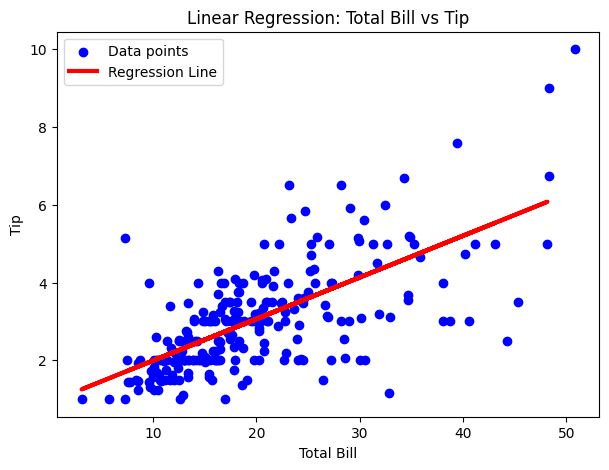

In [27]:

# -------------------------------------------------------------
# 1. LINEAR REGRESSION (Seaborn 'tips' dataset)
# -------------------------------------------------------------
print("===================================================")
print("1. LINEAR REGRESSION – Predict Tip from Total Bill")
print("===================================================")

tips = sns.load_dataset("tips")
display (tips.head())

X = tips[['total_bill']]
y = tips['tip']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Evaluation Metrics
print("\nLinear Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))

# Visualization
plt.figure(figsize=(7,5))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X_test, y_pred, color='red', linewidth=3, label='Regression Line')
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Linear Regression: Total Bill vs Tip")
plt.legend()
plt.show()

***random_state*** is a seed number used to control randomness in machine learning operations so that your results stay reproducible every time you run the code.

test_size=0.2 in a train–test split means:

* 20% of the dataset is used for testing, and

* 80% of the dataset is used for training.

# Logistic Regression

In [28]:
# -------------------------------------------------------------
# 2. LOGISTIC REGRESSION (Seaborn 'titanic' dataset)
# -------------------------------------------------------------
print("\n===================================================")
print("2. LOGISTIC REGRESSION – Titanic Survival Prediction")
# “Using the Titanic dataset, build a logistic regression model
# to predict whether a passenger survived (1) or not (0) based on
# features such as age, sex, fare, etc.”
print("===================================================")

titanic = sns.load_dataset("titanic")
titanic = titanic[['age','fare','sex','survived']].dropna(). # remove missing values

titanic['sex'] = titanic['sex'].map({'male':0,'female':1}) # This is called label encoding.
display(titanic.head())

X = titanic[['age','fare','sex']]
y = titanic['survived']. # Goal: Predict whether a person survived the Titanic (1 = yes, 0 = no)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



logreg = LogisticRegression(max_iter=300)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

## to extract the probability of the positive class.
# Givesthe probability that each test sample belongs to class 1.”
y_prob = logreg.predict_proba(X_test)[:,1]

# Metrics
print("\nLogistic Regression Metrics:")
print(classification_report(y_test, y_pred))




2. LOGISTIC REGRESSION – Titanic Survival Prediction


,age,fare,sex,survived
0,22.0,7.2500,0,0
1,38.0,71.2833,1,1
2,26.0,7.9250,1,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0



Logistic Regression Metrics:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        87
           1       0.68      0.68      0.68        56

    accuracy                           0.75       143
   macro avg       0.74      0.74      0.74       143
weighted avg       0.75      0.75      0.75       143



In Logistic Regression, ***max_iter*** stands for maximum number of iterations the optimization algorithm is allowed to run while trying to find the best model parameters.

max_iter = maximum number of times the algorithm will try to adjust the weights to minimize error.

Meaning:

* 80% of data → training

* 20% of data → testing

random_state=42 ensures the same split every time (reproducibility)

y_prob = logreg.predict_proba(X_test)[:,1]

predict_proba() gives probability for both classes → shape (n_samples, 2)

[:,1] selects the probability of class 1 (survived)

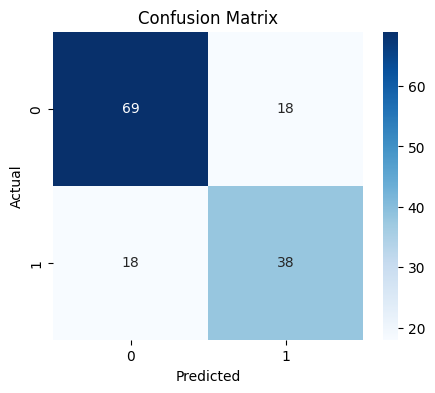

In [9]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



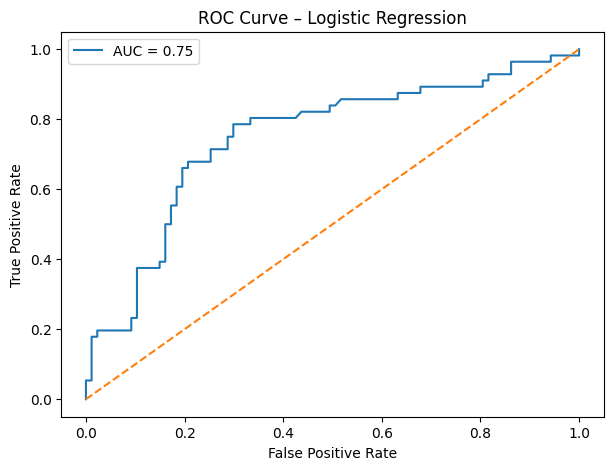

In [10]:
# ROC Curve
fpr, tpr, threshold = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.legend()
plt.show()

* Blue Curve → Your Logistic Regression Model

Shows how well the model distinguishes between:

* * Survived (1)

* * Not Survived (0)

* Orange Dashed Line → Random Guessing

# K-Nearest Neighbours (KNN)


3. KNN CLASSIFICATION – Iris Dataset


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



 KNN Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



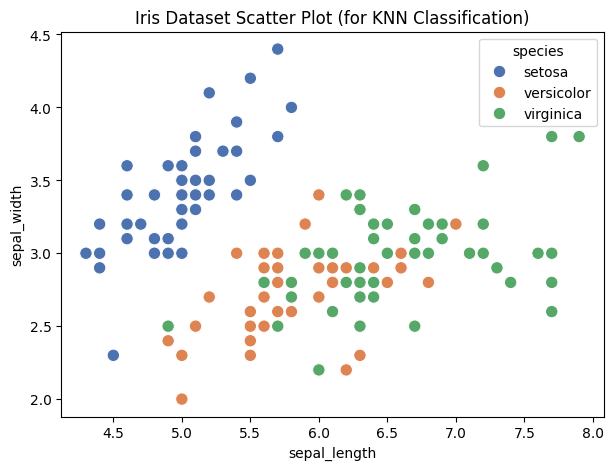

In [30]:
# -------------------------------------------------------------
# 3. KNN CLASSIFIER (Seaborn 'iris' dataset)
# -------------------------------------------------------------
print("\n===================================================")
print("3. KNN CLASSIFICATION – Iris Dataset")
print("===================================================")


# Load dataset
iris = sns.load_dataset("iris")
display (iris.head())

# Features and target
# Removes the species column from the dataset, and Keeps only the numeric features
X = iris.drop("species", axis=1)
y = iris["species"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=7)

# Train the model
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\n KNN Accuracy:", acc)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Simple scatter plot (only first 2 features)
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='sepal_width',
    hue='species',
    palette='deep',
    s=80
)
plt.title("Iris Dataset Scatter Plot (for KNN Classification)")
plt.show()




# K-Means Clustering + Elbow Method


4. K-MEANS CLUSTERING – Iris Dataset


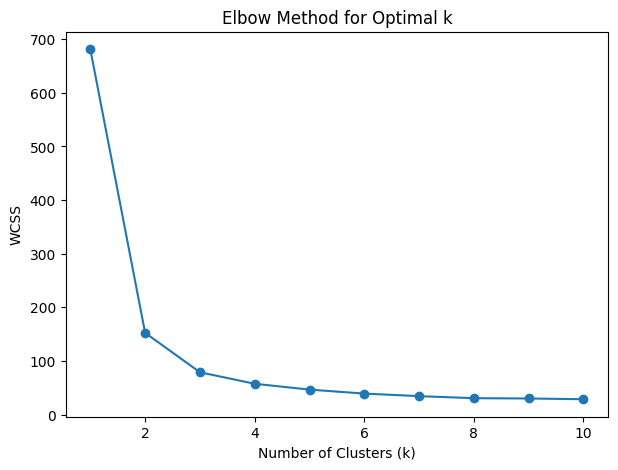

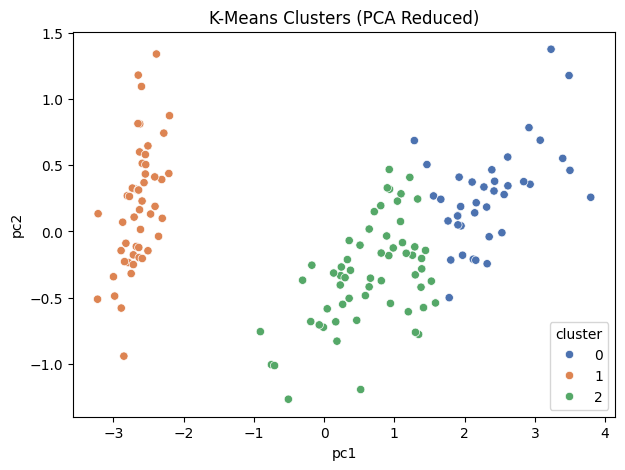

In [31]:
# -------------------------------------------------------------
# 4. K-MEANS CLUSTERING + ELBOW METHOD (Iris dataset)
# -------------------------------------------------------------
print("\n===================================================")
print("4. K-MEANS CLUSTERING – Iris Dataset")
print("===================================================")

X = iris.drop("species", axis=1)

# Elbow Method: To find the optimal number of clusters (k)
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

# Apply KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
iris['cluster'] = kmeans.fit_predict(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
iris_2d = pca.fit_transform(X)
iris['pc1'] = iris_2d[:,0]
iris['pc2'] = iris_2d[:,1]

plt.figure(figsize=(7,5))
sns.scatterplot(data=iris, x="pc1", y="pc2", hue="cluster", palette="deep")
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()



# Principal Component Analysis (PCA)

Explained variance ratio: [0.72962445 0.22850762]

 PC1 and PC2 explain ~96% of total variance.



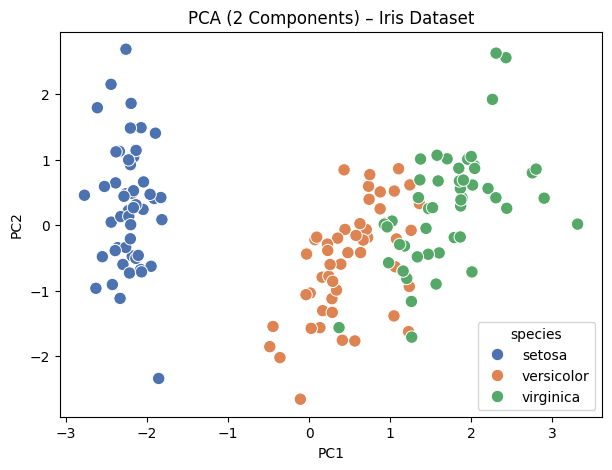

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
iris = sns.load_dataset("iris")

# Extract features
X = iris.drop("species", axis=1)
y = iris["species"]

# Standardize (very important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add to dataframe for plotting
iris["PC1"] = X_pca[:, 0]
iris["PC2"] = X_pca[:, 1]

# Print explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\n PC1 and PC2 explain ~96% of total variance.\n")

# Scatter plot of PCA components
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=iris,
    x="PC1",
    y="PC2",
    hue="species",
    palette="deep",
    s=80
)
plt.title("PCA (2 Components) – Iris Dataset")
plt.show()
